# 03｜Process Signal EDA

## 專案名稱
**半導體蝕刻製程智慧分析與虛擬量測**  
Semiconductor Etch Process Intelligence & Virtual Metrology

---

## 這份 Notebook 要做什麼？

前一份 02 已經看到一個很明顯的現象：**10 個 Lot 的 Mean Si Etch 都會隨著 Wafer Number 往後而下降**。

所以到 03，我不再重做 Quality EDA，而是改看 Process 端。我想確認的是：

> Process signals 本身是不是也會跟著同一個 Lot 裡的 wafer sequence 一起變化？

這件事很重要。因為如果 Process X 和 Quality Y 都同時跟著 `wafer_number` 變化，之後直接把全部 wafer 混在一起算 correlation，很容易把「共同跟 sequence 變化」誤認成真正的 Process–Quality 關係。

這份 Notebook 主要會做幾件事：

1. 看 27 個可用 Process Features 的 time-series 長什麼樣。
2. 沿用 01 已確認的 terminal-gap 規則。
3. 找出每片 wafer 的 Main Active Process Window。
4. 檢查 96 片 wafer 的 Main Active Duration 是否穩定。
5. 把每片 wafer 的 Main-process signal 平均值整理出來。
6. 檢查這些 Process Signals 是否也會隨 Wafer Sequence 改變。
7. 輸出後面 04、05、06 可以直接使用的 Process summary。

### 這裡先說清楚分析範圍

這一份仍然只是 Process EDA，所以我不會把任何 sequence trend 直接說成造成 Quality 變化的原因。

另外，後面使用的 `80% of wafer-level max SourceRFLoadPower` 是我根據這份資料 waveform 設定的分析規則，用來抓主要高功率區段；它不是設備原廠提供的正式製程 step specification。


## 1. 載入套件

這一格先把資料處理、NetCDF 讀取、數值計算和繪圖會用到的套件載入。這裡還沒有開始分析資料。


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from netCDF4 import Dataset

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 150)

print("套件載入完成")

套件載入完成


### 這個輸出代表什麼？

畫面顯示套件成功載入，代表分析環境可以正常使用。

這一格本身還沒有讀任何 wafer 資料，也沒有產生分析結果，所以目前只能確認「環境準備完成」，不能從這裡解讀製程狀況。


## 2. 設定 Raw、Interim 和 Processed 資料路徑

03 需要讀 Raw NetCDF，因為我要看完整的 Process time series，這些資訊不是只靠 wafer-level CSV summary 就能還原。

不過資料規則不會重新定義，而是沿用前面的結果：

### 從 01 沿用
- `usable_process_features.csv`
- `process_qc_summary.csv`
- `lot_summary_clean.csv`

### 從 02 沿用
- `lot_sequence_summary.csv`

也就是說，03 只負責往 Process time-series 繼續分析，不會重新決定哪些 features 可用、Lot 怎麼定義，或重新改寫 02 的 Quality sequence 結論。


In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

process_path = RAW_DATA_DIR / "Process_data.nc"
dictionary_path = RAW_DATA_DIR / "Dictionary_process.nc"

usable_features_path = (
    INTERIM_DATA_DIR / "usable_process_features.csv"
)
process_qc_path = (
    INTERIM_DATA_DIR / "process_qc_summary.csv"
)
lot_summary_path = (
    INTERIM_DATA_DIR / "lot_summary_clean.csv"
)
quality_sequence_path = (
    PROCESSED_DATA_DIR / "lot_sequence_summary.csv"
)

required_paths = [
    process_path,
    dictionary_path,
    usable_features_path,
    process_qc_path,
    lot_summary_path,
    quality_sequence_path,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

assert not missing_paths, (
    "缺少必要上游檔案："
    + ", ".join(str(path) for path in missing_paths)
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("專案根目錄：", PROJECT_ROOT)
print("Raw Process：", process_path)
print("Dictionary：", dictionary_path)
print("01 QC Artifacts：", INTERIM_DATA_DIR)
print("02 Quality Sequence：", quality_sequence_path)

專案根目錄： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence
Raw Process： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\raw\Process_data.nc
Dictionary： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\raw\Dictionary_process.nc
01 QC Artifacts： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\interim
02 Quality Sequence： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed\lot_sequence_summary.csv


### 這個輸出代表什麼？

輸出把專案根目錄、Raw Process、Dictionary，以及 01、02 產出的上游檔案路徑都列出來了。

這代表 03 使用的資料來源是：

`01 的 QC 規則 + 02 的 Quality sequence 結果 + Raw Process traces`

所以後面如果出現新的 Process 結果，可以確認它是接在原本 pipeline 上繼續分析，而不是又從 Raw Data 重新建立另一套規則。


## 3. 載入上游結果，先固定 03 的分析前提

在正式做 Process EDA 前，我先確認前面幾份資料沒有被改掉。

這裡會檢查：

- usable process features 是否還是 27 個
- process QC 是否還是 96 片 wafer
- Lot metadata 是否還是 10 個 Lots
- 02 的 sequence summary 是否還是 10 個 Lots
- 02 的 Mean Si Etch slope 是否仍然是 10 / 10 Lots 都為負

如果這些基本條件不一致，03 後面的結果就不能和前面的 Notebook 接起來。


In [3]:
usable_features_df = pd.read_csv(usable_features_path)
process_qc_df = pd.read_csv(process_qc_path)
lot_summary_df = pd.read_csv(lot_summary_path)
quality_sequence_df = pd.read_csv(quality_sequence_path)

usable_process_features = usable_features_df["feature"].tolist()

lot_summary_df["date"] = pd.to_datetime(
    lot_summary_df["date"],
    errors="raise",
)

assert len(usable_process_features) == 27
assert len(process_qc_df) == 96
assert len(lot_summary_df) == 10
assert len(quality_sequence_df) == 10

quality_negative_lots = int(
    (
        quality_sequence_df[
            "mean_si_etch_slope_per_wafer"
        ] < 0
    ).sum()
)

assert quality_negative_lots == 10

print("Usable Process Features：", len(usable_process_features))
print("Process QC Rows：", len(process_qc_df))
print("Lot Metadata Rows：", len(lot_summary_df))
print(
    "02 Mean Si Etch negative-slope Lots：",
    quality_negative_lots,
    "/ 10",
)

Usable Process Features： 27
Process QC Rows： 96
Lot Metadata Rows： 10
02 Mean Si Etch negative-slope Lots： 10 / 10


### 這個結果實際告訴我們什麼？

目前輸出確認：

- 可用的 Process Features = **27**
- Process Wafers = **96**
- Lots = **10**
- Mean Si Etch 的 sequence slope = **10 / 10 Lots 都是負值**

所以 02 的 Quality sequence 現象在資料傳到 03 時沒有改變。

接下來真正要確認的就是：**Process 端是不是也有類似的 wafer-sequence structure。** 如果有，後面做 Process–Quality relationship 時就一定要把 sequence 影響考慮進去。


# Part A｜Raw Process Trace 與時間結構

## 4. 建立 Process Group Metadata，並和 01 的 QC / Lot Metadata 對齊

Raw NetCDF 裡每片 wafer 的 group name 是：

`Day_YYYY_MM_DD_Wafer_XX`

這一段先從 group name 解析出：

- process date
- wafer number
- experiment key

再用 01 的 `lot_summary_clean.csv` 把日期對回 Lot。

我也會一起確認：

- Raw NetCDF 是否真的有 96 個 groups
- group names 能不能和 `process_qc_summary.csv` 一一對上
- 每個 Lot 的 wafer 數量是否和 01 的 metadata 一致

這一步只是確認資料身份和對應關係，還不做 Process statistics。


In [4]:
def parse_process_group_name(group_name):
    match = re.fullmatch(
        r"Day_(\d{4}_\d{2}_\d{2})_Wafer_(\d+)",
        group_name,
    )

    if match is None:
        raise ValueError(
            f"無法解析 Process Group Name：{group_name}"
        )

    process_date = pd.to_datetime(
        match.group(1).replace("_", "-"),
        errors="raise",
    )
    wafer_number = int(match.group(2))

    experiment_key = (
        process_date.strftime("%Y-%m-%d")
        + "_"
        + f"{wafer_number:02d}"
    )

    return process_date, wafer_number, experiment_key


with Dataset(process_path, "r") as process_ds:
    process_groups = list(process_ds.groups.keys())

assert len(process_groups) == 96
assert set(process_groups) == set(process_qc_df["group_name"])

group_records = []

date_to_lot = (
    lot_summary_df
    .set_index("date")["lot_number"]
    .to_dict()
)

for group_name in process_groups:
    process_date, wafer_number, experiment_key = (
        parse_process_group_name(group_name)
    )

    assert process_date in date_to_lot

    group_records.append(
        {
            "group_name": group_name,
            "experiment_key": experiment_key,
            "date": process_date,
            "lot_number": int(date_to_lot[process_date]),
            "wafer_number": wafer_number,
        }
    )

process_group_metadata = (
    pd.DataFrame(group_records)
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

assert process_group_metadata["experiment_key"].is_unique

observed_process_counts = (
    process_group_metadata
    .groupby("lot_number")
    .size()
    .rename("observed_wafers")
)

expected_process_counts = (
    lot_summary_df
    .set_index("lot_number")["wafers"]
)

count_check = (
    pd.concat(
        [expected_process_counts, observed_process_counts],
        axis=1,
    )
    .reset_index()
)

count_check["match"] = (
    count_check["wafers"]
    == count_check["observed_wafers"]
)

assert count_check["match"].all()

print("Raw Process Groups：", len(process_groups))
display(count_check)

Raw Process Groups： 96


,lot_number,wafers,observed_wafers,match
0,1,10,10,True
1,2,10,10,True
2,3,10,10,True
3,4,10,10,True
4,5,10,10,True
5,6,10,10,True
6,7,6,6,True
7,8,10,10,True
8,9,10,10,True
9,10,10,10,True


### 這個結果實際告訴我們什麼？

Raw Process 一共有 **96 個 groups**，而且每個 Lot 的實際 wafer 數都和 01 的 metadata 一致：

- Lot 1–6、8–10：各 **10 片**
- Lot 7：**6 片**

表格中的 `match` 全部都是 `True`，表示 Raw Process group 和前面整理好的 Lot 資訊沒有錯位。

因此後面 03 的 Process sequence analysis 可以使用完整 **96 片 Process Wafers**。這和 Quality 資料只有 88 片是不同的事情，這裡不應該先把沒有 Quality label 的 Process wafers 丟掉。


## 5. 沿用 01 的 Terminal-Gap 規則，建立統一的 Process Loader

01 已經確認：

- 一般 sampling interval 約 **0.2 秒**
- **69 / 96** 片 wafer 有大於 1 秒的 large gap
- 這些 large gaps 都出現在最後一個 transition

所以 03 不重新發明處理方式，而是直接沿用同一條規則：

> 如果最後一個 time interval 大於 1 秒，就把最後一筆 sample 排除在 main continuous segment 之外；Raw Data 本身不刪除。

這個 loader 會統一做幾件事：

1. 解碼 dictionary-encoded process values。
2. 只保留 27 個 usable features。
3. 檢查時間軸是否嚴格遞增。
4. 如果出現 >1 秒 gap，確認它只能出現在 terminal transition。
5. 建立從 0 秒開始的 `elapsed_seconds`，但仍保留原本的 `process_time`。

後面所有 wafer 都會共用這一套 loader，避免不同分析段落各自處理一次。


In [5]:
def clean_feature_name(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return str(value)


def get_main_continuous_segment(
    times,
    data,
    gap_threshold=1.0,
):
    times = np.asarray(times, dtype=float)
    data = np.asarray(data)

    if len(times) != len(data):
        raise ValueError("times 與 process data 長度不一致")

    time_diff = np.diff(times)

    if len(time_diff) > 0 and np.any(time_diff <= 0):
        raise ValueError("Process time axis 不是 strictly increasing")

    large_gap_indices = np.where(
        time_diff > gap_threshold
    )[0]

    if len(large_gap_indices) > 0:
        if not (
            len(large_gap_indices) == 1
            and large_gap_indices[0] == len(time_diff) - 1
        ):
            raise ValueError(
                "偵測到非 terminal 的 >1 s gap，與 01 QC 決策不一致"
            )

        return times[:-1], data[:-1], True

    return times, data, False


with Dataset(dictionary_path, "r") as dictionary_ds:
    decoder = dictionary_ds["data"][:]


def load_process_wafer(group_name):
    with Dataset(process_path, "r") as process_ds:
        group = process_ds.groups[group_name]

        feature_names = [
            clean_feature_name(value)
            for value in group["feature"][:]
        ]

        feature_index = {
            feature: index
            for index, feature in enumerate(feature_names)
        }

        missing_features = [
            feature
            for feature in usable_process_features
            if feature not in feature_index
        ]

        if missing_features:
            raise ValueError(
                f"{group_name} 缺少 usable features: {missing_features}"
            )

        usable_indices = [
            feature_index[feature]
            for feature in usable_process_features
        ]

        encoded_data = group["data"][:, usable_indices]
        decoded_data = decoder[encoded_data]
        raw_times = np.asarray(group["times"][:], dtype=float)

    main_times, main_data, had_terminal_gap = (
        get_main_continuous_segment(
            raw_times,
            decoded_data,
        )
    )

    process_df = pd.DataFrame(
        main_data,
        columns=usable_process_features,
    )

    process_df.insert(0, "process_time", main_times)

    process_df["elapsed_seconds"] = (
        process_df["process_time"]
        - process_df["process_time"].iloc[0]
    )

    return process_df, raw_times, had_terminal_gap


print("Process Loader 建立完成")

Process Loader 建立完成


### 這個輸出代表什麼？

這一格顯示 Process Loader 已經成功建立。

它還沒有產生新的製程結論，但後面的範例 wafer、96 片 summary 和 edge-case 檢查都會用同一套 decoding 與 terminal-gap 規則。這樣可以避免同一份資料在不同 cell 被不同方式處理。


## 6. 先用固定的一片 Wafer 檢查時間結構

為了讓每次執行都看到同一個例子，這裡固定使用：

`Day_2024_07_02_Wafer_01`

我先確認幾件最基本的事情：

- Raw time points 有多少
- 有沒有 terminal gap
- 排除 terminal transition 後還剩多少 continuous points
- continuous segment 多長
- sampling interval 是否還是大約 0.2 秒

這一段的目的只是先確認 loader 的結果和 01 的 QC 一致。


In [6]:
example_group_name = "Day_2024_07_02_Wafer_01"

assert example_group_name in process_groups

example_process_df, example_raw_times, example_terminal_gap = (
    load_process_wafer(example_group_name)
)

example_duration = (
    example_process_df["process_time"].iloc[-1]
    - example_process_df["process_time"].iloc[0]
)

median_sampling_interval = np.median(
    np.diff(example_process_df["process_time"])
)

print("Example Wafer：", example_group_name)
print("Raw Time Points：", len(example_raw_times))
print("Main Continuous Segment Points：", len(example_process_df))
print("Terminal Gap：", example_terminal_gap)
print("Continuous Segment Duration：", round(example_duration, 2), "seconds")
print("Median Sampling Interval：", round(median_sampling_interval, 4), "seconds")
print(
    "Approximate Sampling Frequency：",
    round(1 / median_sampling_interval, 2),
    "Hz",
)

example_process_df.head()

Example Wafer： Day_2024_07_02_Wafer_01
Raw Time Points： 3245
Main Continuous Segment Points： 3244
Terminal Gap： True
Continuous Segment Duration： 648.6 seconds
Median Sampling Interval： 0.2 seconds
Approximate Sampling Frequency： 5.0 Hz


,process_time,Stat3_Etch_MV_EpdIntensity,Stat3_Etch_MV_ForeLinePressure,Stat3_Etch_MV_Gas1Flow,Stat3_Etch_MV_Gas2Flow,Stat3_Etch_MV_Gas4Flow,Stat3_Etch_MV_Gas5Flow,Stat3_Etch_MV_Gas7Flow,Stat3_Etch_MV_Heater1Temp,Stat3_Etch_MV_Heater2Temp,Stat3_Etch_MV_Heater3Temp,Stat3_Etch_MV_Heater4Temp,Stat3_Etch_MV_HeliumBPFlow,Stat3_Etch_MV_HeliumBPPressure,Stat3_Etch_MV_PlatenDcBias,Stat3_Etch_MV_PlatenRFLoadCapacitor,Stat3_Etch_MV_PlatenRFLoadPower,Stat3_Etch_MV_PlatenRFPeakToPeak,Stat3_Etch_MV_PlatenRFReflectedPower,Stat3_Etch_MV_PlatenRFTuningCapacitor,Stat3_Etch_MV_Pressure,Stat3_Etch_MV_SourceRF2PeakToPeak,Stat3_Etch_MV_SourceRF2TuningCapacitor,Stat3_Etch_MV_SourceRFLoadPower,Stat3_Etch_MV_SourceRFPeakToPeak,Stat3_Etch_MV_SourceRFReflectedPower,Stat3_Etch_MV_SourceRFTuningCapacitor,Stat3_Etch_MV_moriInnerCurrent,elapsed_seconds
0,92.77,791.590942,36.011841,0.23,4.12,4.94,0.0,2.10,1371.099976,54.200001,10.2,59.700001,0.0,0.014649,0.0,56.48671,0.0,0.0,0.0,14.267404,0.0014,0.0,1.0,0.0,0.0,0.061037,3.0,0.0,0.0
1,92.97,791.590942,37.232582,0.26,4.08,4.97,0.0,2.01,1371.099976,54.200001,10.2,59.700001,0.0,0.014039,0.0,49.54985,0.0,0.0,0.0,29.648731,0.0013,0.0,1.0,0.0,0.0,0.000000,3.0,0.0,0.2
2,93.17,791.590942,37.232582,0.26,4.08,4.97,0.0,2.01,1371.099976,54.200001,10.2,59.700001,0.0,0.014039,0.0,49.54985,0.0,0.0,0.0,29.648731,0.0013,0.0,1.0,0.0,0.0,0.000000,3.0,0.0,0.4
3,93.37,791.590942,37.232582,0.26,4.08,4.97,0.0,2.01,1371.099976,54.200001,10.2,59.700001,0.0,0.014039,0.0,49.54985,0.0,0.0,0.0,29.648731,0.0013,0.0,1.0,0.0,0.0,0.000000,3.0,0.0,0.6
4,93.57,791.590942,37.232582,0.26,4.08,4.97,0.0,2.01,1371.099976,54.200001,10.2,59.700001,0.0,0.014039,0.0,49.54985,0.0,0.0,0.0,29.648731,0.0013,0.0,1.0,0.0,0.0,0.000000,3.0,0.0,0.8


### 這個結果實際告訴我們什麼？

這片範例 wafer 的結果是：

- Raw time points = **3,245**
- Main continuous segment = **3,244 points**
- Terminal gap = **True**
- Continuous segment duration ≈ **648.6 秒**
- Median sampling interval = **0.2 秒**
- Sampling frequency ≈ **5 Hz**

也就是說，這片 wafer 最後確實多了一個 terminal gap；排除最後一筆後，主要連續資料仍然保持約 0.2 秒一次的取樣。

這和 01 的 QC 結果一致，所以 03 的 loader 沒有改掉上游的時間軸定義。

另外，`process_time` 在這裡只當作單片 wafer 內的數值時間軸，不把它當成跨 wafer 的 absolute timestamp；畫圖時會改用從 0 開始的 `elapsed_seconds`，比較直觀。


# Part B｜Process Signal Behavior

## 7. 先看一片 Wafer 裡 27 個 Process Signals 怎麼變

這一段先在完整 continuous segment 上計算每個 feature 的：

- Min / Max / Mean / Std
- Range
- Unique Values

我不是要在這裡做 feature selection，而是先了解這些 signal 大概屬於哪一種型態，例如：

- 幾乎維持固定
- 只有幾個離散狀態
- 持續變動或週期切換

這也能幫助後面判斷，為什麼不能把所有 signals 都只用「整段製程平均值」來理解。


In [7]:
example_signal_summary = pd.DataFrame(
    {
        "min": example_process_df[
            usable_process_features
        ].min(),
        "max": example_process_df[
            usable_process_features
        ].max(),
        "mean": example_process_df[
            usable_process_features
        ].mean(),
        "std": example_process_df[
            usable_process_features
        ].std(ddof=0),
        "n_unique": example_process_df[
            usable_process_features
        ].nunique(),
    }
)

example_signal_summary["range"] = (
    example_signal_summary["max"]
    - example_signal_summary["min"]
)

example_signal_summary["is_constant_within_wafer"] = (
    example_signal_summary["n_unique"] == 1
)

n_constant_example = int(
    example_signal_summary["is_constant_within_wafer"].sum()
)

n_changing_example = (
    len(example_signal_summary)
    - n_constant_example
)

print("有變化的 Process Features：", n_changing_example)
print("完全固定的 Process Features：", n_constant_example)

example_signal_summary.sort_values(
    ["n_unique", "std"]
)[
    [
        "min",
        "max",
        "mean",
        "std",
        "range",
        "n_unique",
        "is_constant_within_wafer",
    ]
]

有變化的 Process Features： 27
完全固定的 Process Features： 0


,min,max,mean,std,range,n_unique,is_constant_within_wafer
Stat3_Etch_MV_Heater1Temp,1371.000000,1371.099976,1371.013916,0.034653,0.099976,2,False
Stat3_Etch_MV_SourceRF2TuningCapacitor,1.000000,2.000000,1.943896,0.230122,1.000000,2,False
Stat3_Etch_MV_EpdIntensity,0.123000,791.590942,18.665403,119.715904,791.467957,2,False
Stat3_Etch_MV_Heater3Temp,10.100000,10.300000,10.162731,0.049361,0.200000,3,False
Stat3_Etch_MV_SourceRFTuningCapacitor,1.000000,4.000000,3.007707,0.232134,3.000000,3,False
Stat3_Etch_MV_Heater4Temp,59.700001,60.200001,59.995281,0.098066,0.500000,6,False
Stat3_Etch_MV_Heater2Temp,54.200001,54.700001,54.423706,0.124802,0.500000,6,False
Stat3_Etch_MV_SourceRF2PeakToPeak,0.000000,60.121464,0.184579,3.169480,60.121464,12,False
Stat3_Etch_MV_moriInnerCurrent,0.000000,10.050966,9.826375,1.302376,10.050966,24,False
Stat3_Etch_MV_Gas7Flow,1.850000,2.130000,2.002830,0.035902,0.280000,29,False


### 這個結果實際告訴我們什麼？

在這片範例 wafer 的 continuous segment 裡：

- 27 個 usable features **全部都有時間上的變化**
- 完全固定的 feature = **0**

但它們的變化方式差很多。

例如：

- `Heater1Temp` 大約只在 **1371.0–1371.1** 之間變動，而且只有少數離散值。
- `EpdIntensity` 也只有少數狀態，但會從大約 **791.6** 切到接近 0，這種資訊主要來自「狀態切換」，不是細小連續波動。
- RF / bias 類 signals 的 unique values 很多，屬於比較動態的連續訊號。

所以這裡最重要的意思是：**「有變化」不代表大家的變化形式一樣，`n_unique` 少也不代表沒有資訊。**

另外，各 sensor 的單位和尺度都不同，因此不能因為某個 feature 數值看起來比較大，就直接說它比較重要。


## 8. 畫幾個代表性的 Time-Series Pattern

接著我挑 11 個代表性 signals 畫 time series。

這裡不做統計排名，目的只是直接看 waveform，確認資料裡大致有哪些型態，例如：

- startup / shutdown transition
- 長時間主要製程區段
- cyclic switching
- stable high-level plateau

這一步主要是幫下一節決定 Main Active Process Window 要怎麼抓。


Representative Signals： 11


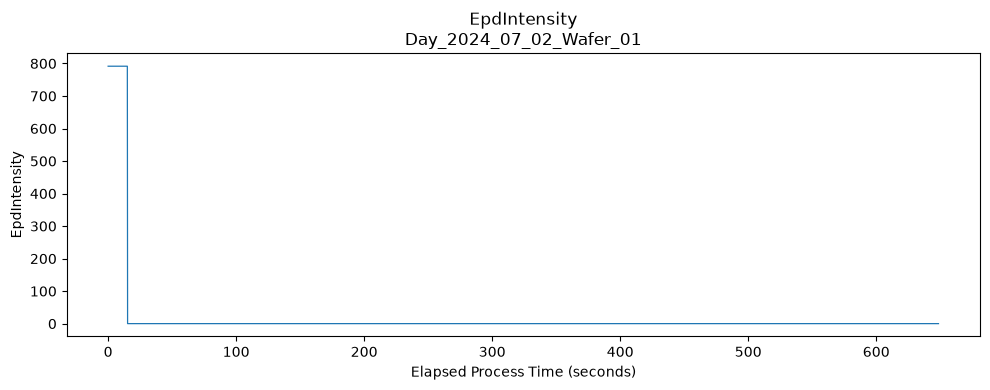

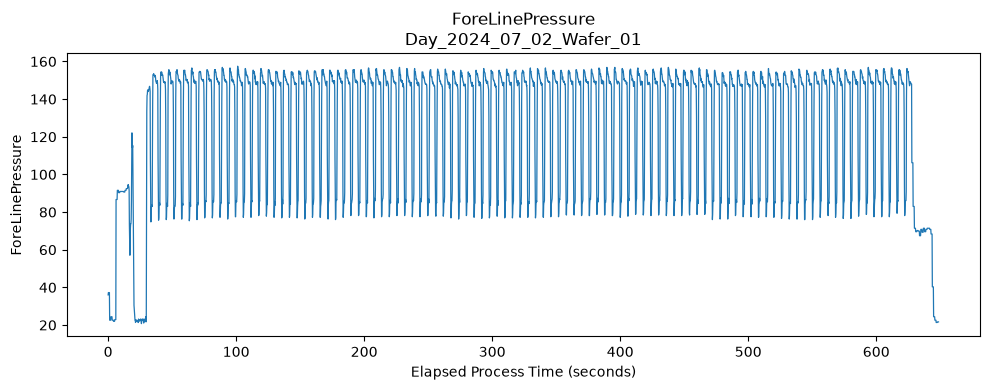

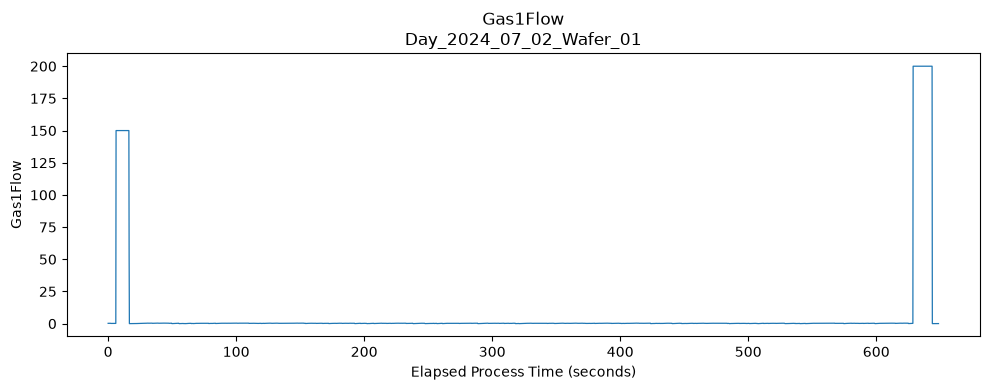

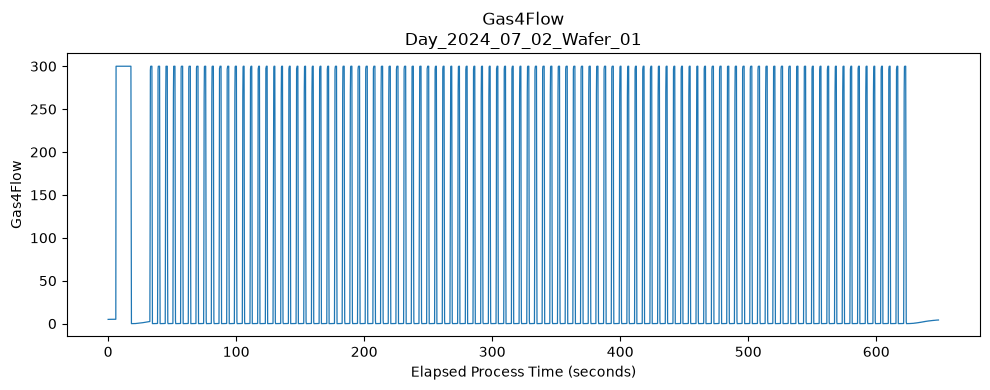

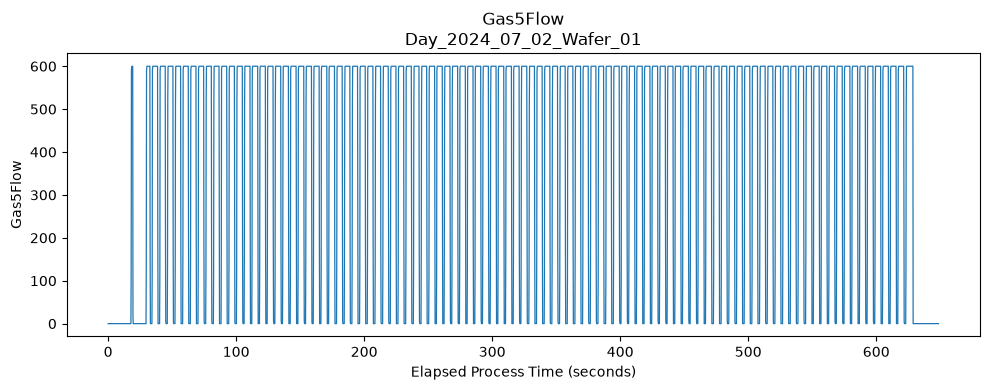

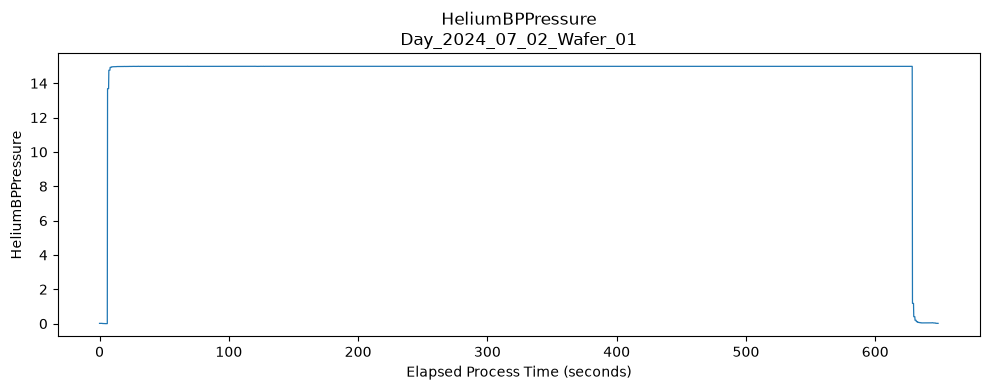

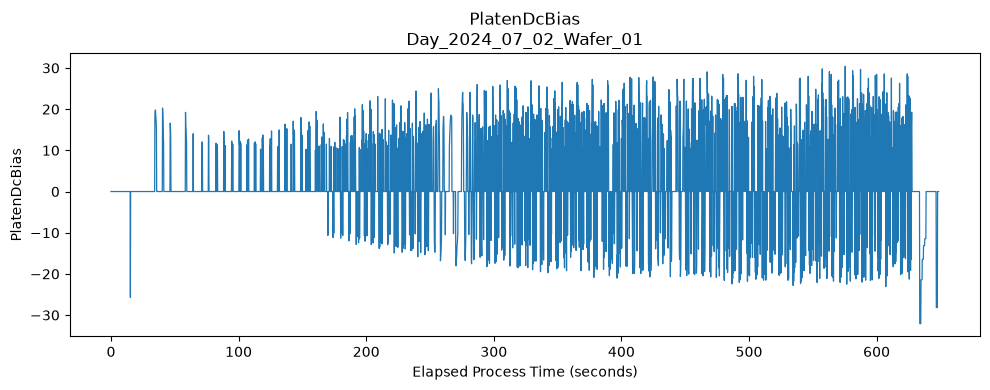

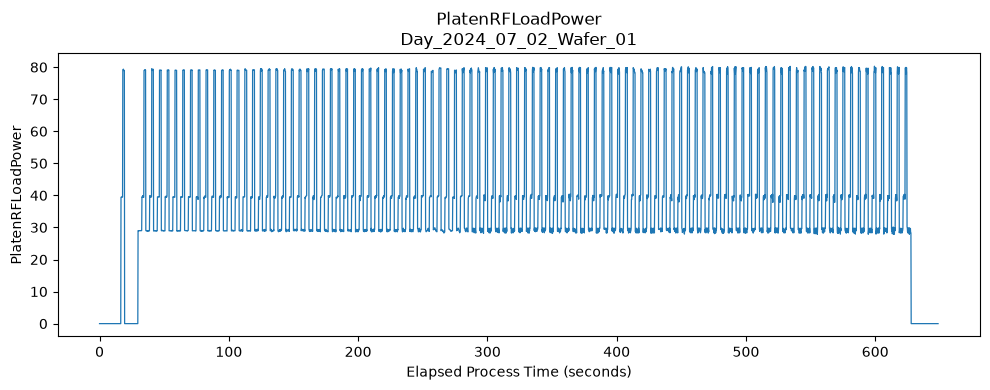

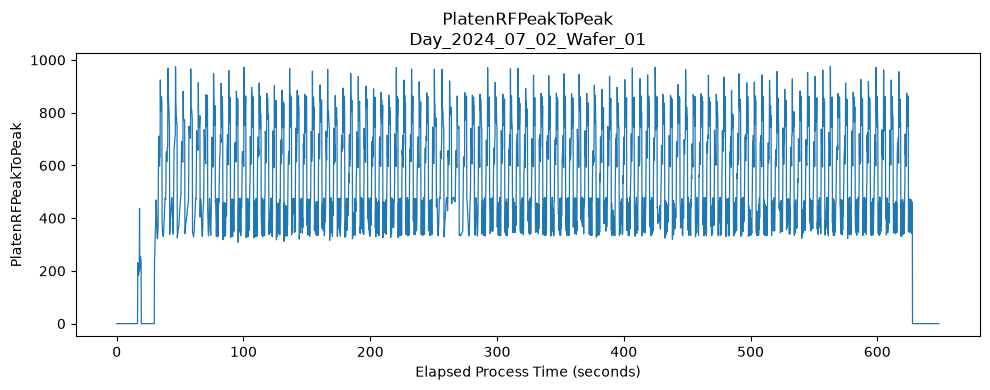

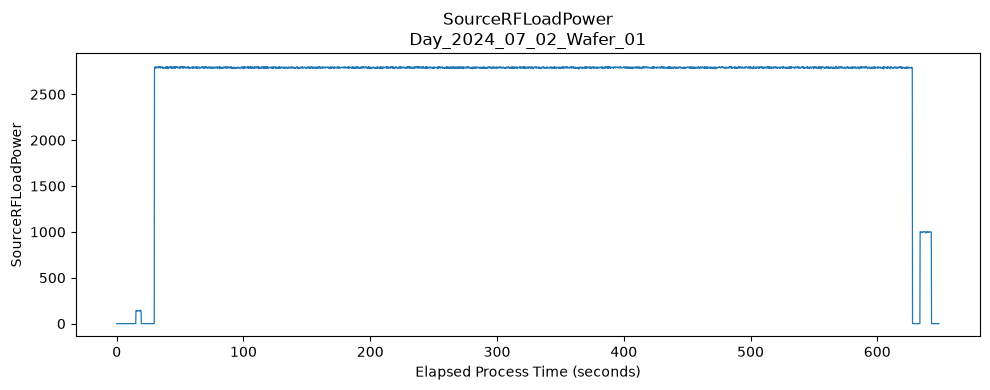

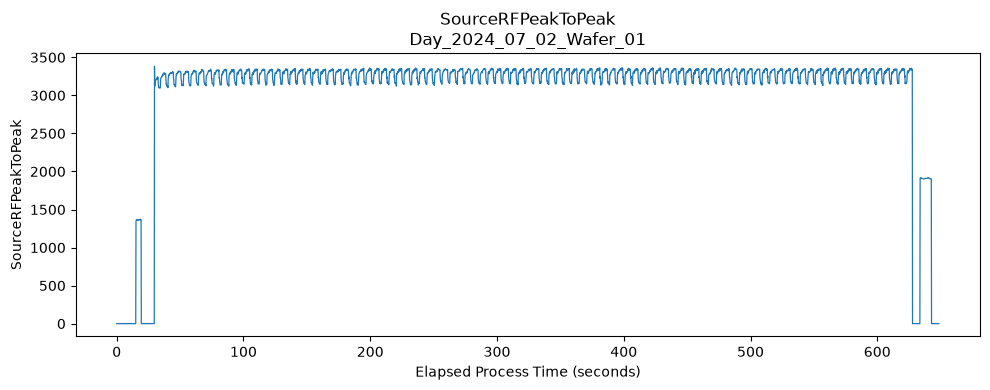

In [8]:
candidate_signals = [
    "Stat3_Etch_MV_EpdIntensity",
    "Stat3_Etch_MV_ForeLinePressure",
    "Stat3_Etch_MV_Gas1Flow",
    "Stat3_Etch_MV_Gas4Flow",
    "Stat3_Etch_MV_Gas5Flow",
    "Stat3_Etch_MV_HeliumBPPressure",
    "Stat3_Etch_MV_PlatenDcBias",
    "Stat3_Etch_MV_PlatenRFLoadPower",
    "Stat3_Etch_MV_PlatenRFPeakToPeak",
    "Stat3_Etch_MV_SourceRFLoadPower",
    "Stat3_Etch_MV_SourceRFPeakToPeak",
]

selected_signals = [
    feature
    for feature in candidate_signals
    if feature in example_process_df.columns
]

print("Representative Signals：", len(selected_signals))

for feature in selected_signals:
    short_name = feature.replace("Stat3_Etch_MV_", "")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        example_process_df["elapsed_seconds"],
        example_process_df[feature],
        linewidth=0.9,
    )
    ax.set_xlabel("Elapsed Process Time (seconds)")
    ax.set_ylabel(short_name)
    ax.set_title(f"{short_name}\n{example_group_name}")
    plt.tight_layout()
    plt.show()

### 這些圖實際告訴我們什麼？

從目前的 waveform 可以大致看出三種型態：

**比較像 transition 主導的 signal**
- `EpdIntensity`
- `Gas1Flow`

**有明顯 cyclic / switching pattern**
- `ForeLinePressure`
- `Gas4Flow`
- `Gas5Flow`
- `PlatenDcBias`
- `PlatenRFLoadPower`
- `PlatenRFPeakToPeak`

**主要呈現長時間高 level / plateau**
- `HeliumBPPressure`
- `SourceRFLoadPower`
- `SourceRFPeakToPeak`

其中 `SourceRFLoadPower` 最適合拿來抓主要製程區段：它大約在 **30 秒後進入長時間約 2800 的高功率平台，直到約 628 秒才退出**。

所以後面用它來定義 Main Active Window 是有 waveform 依據的，而不是隨便挑一個 sensor。

不過這裡只描述圖上看得到的 pattern。我不會把 `Gas4`、`Gas5` 自行解釋成特定氣體，也不會只靠 waveform 就猜設備裡真正發生了哪個物理機制。


# Part C｜Main Active Process Window

## 9. 定義這份資料的 Main Active Window

這裡使用：

`SourceRFLoadPower >= 0.8 × 該 Wafer 的 SourceRFLoadPower 最大值`

先找到所有符合條件的連續區段，再取其中**最長的一段**當作 Main Active Window。

我沒有直接固定切 30–628 秒，因為不同 wafer 的主要製程區段在各自 recorded trace 裡，起始位置可能不一樣。

### 需要注意

80% 是這個專案根據目前 waveform 設定的分析 threshold。它只是用來把主要長時間高功率 plateau 找出來，**不是設備官方提供的 setpoint 或 step boundary**。


Source RF Load Power Max： 2806.48
80% Active Threshold： 2245.19
Main Start： 29.8
Main End： 627.6
Main Duration： 597.8
Main Samples： 2990


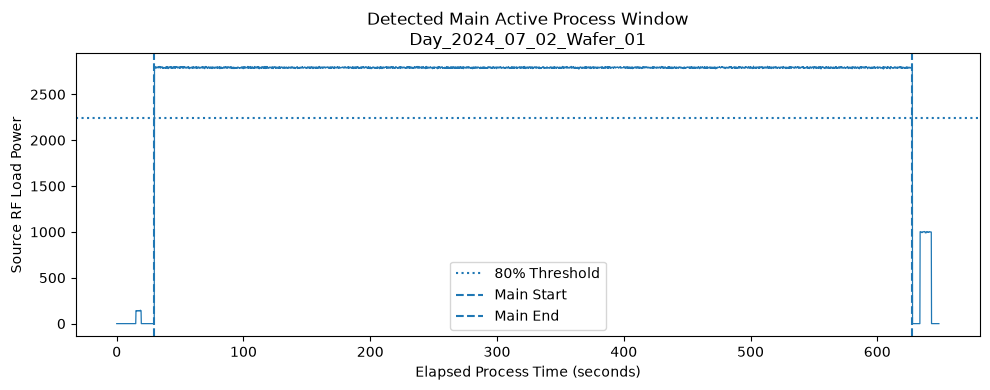

In [9]:
SOURCE_POWER_FEATURE = "Stat3_Etch_MV_SourceRFLoadPower"
ACTIVE_THRESHOLD_RATIO = 0.80


def detect_main_active_window(
    process_df,
    feature_name=SOURCE_POWER_FEATURE,
    threshold_ratio=ACTIVE_THRESHOLD_RATIO,
):
    if not 0 < threshold_ratio < 1:
        raise ValueError("threshold_ratio 必須介於 0 與 1")

    signal = process_df[feature_name].to_numpy(dtype=float)

    if not np.isfinite(signal).all():
        raise ValueError("Main-window signal 含有 NaN / Inf")

    signal_max = signal.max()

    if signal_max <= 0:
        raise ValueError("Main-window signal maximum 必須 > 0")

    threshold = threshold_ratio * signal_max
    active_mask = signal >= threshold

    changes = np.diff(
        active_mask.astype(int),
        prepend=0,
        append=0,
    )

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    if len(starts) == 0:
        raise ValueError("找不到 Main Active Process Window")

    lengths = ends - starts
    longest_index = int(np.argmax(lengths))

    start_index = int(starts[longest_index])
    end_index = int(ends[longest_index])

    main_df = process_df.iloc[
        start_index:end_index
    ].copy()

    start_time = float(main_df["elapsed_seconds"].iloc[0])
    end_time = float(main_df["elapsed_seconds"].iloc[-1])

    return {
        "threshold": float(threshold),
        "start_index": start_index,
        "end_index": end_index,
        "start_time": start_time,
        "end_time": end_time,
        "duration_seconds": end_time - start_time,
        "n_samples": len(main_df),
        "main_df": main_df,
    }


example_main_window = detect_main_active_window(
    example_process_df
)

print(
    "Source RF Load Power Max：",
    round(
        example_process_df[SOURCE_POWER_FEATURE].max(),
        2,
    ),
)
print(
    "80% Active Threshold：",
    round(example_main_window["threshold"], 2),
)
print(
    "Main Start：",
    round(example_main_window["start_time"], 2),
)
print(
    "Main End：",
    round(example_main_window["end_time"], 2),
)
print(
    "Main Duration：",
    round(example_main_window["duration_seconds"], 2),
)
print(
    "Main Samples：",
    example_main_window["n_samples"],
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    example_process_df["elapsed_seconds"],
    example_process_df[SOURCE_POWER_FEATURE],
    linewidth=0.9,
)
ax.axhline(
    example_main_window["threshold"],
    linestyle=":",
    label="80% Threshold",
)
ax.axvline(
    example_main_window["start_time"],
    linestyle="--",
    label="Main Start",
)
ax.axvline(
    example_main_window["end_time"],
    linestyle="--",
    label="Main End",
)
ax.set_xlabel("Elapsed Process Time (seconds)")
ax.set_ylabel("Source RF Load Power")
ax.set_title(
    f"Detected Main Active Process Window\n{example_group_name}"
)
ax.legend()
plt.tight_layout()
plt.show()

### 這個結果實際告訴我們什麼？

以範例 wafer 來看：

- Source RF Load Power 最大值 ≈ **2806.48**
- 80% threshold ≈ **2245.19**
- Main Start ≈ **29.8 秒**
- Main End ≈ **627.6 秒**
- Main Duration ≈ **597.8 秒**
- Main Samples = **2,990**

從圖上可以看到，Start 和 End 都落在主要長時間高功率 plateau 的前後，而 startup / shutdown transition 沒有被混進去。

所以對這片 wafer 來說，80% threshold 確實抓到了我想分析的主要製程區段。這支持它作為目前資料的 EDA heuristic，但仍然不能把它說成設備官方定義。


## 10. 把同一套 Main Active Window 套到全部 96 片 Wafer

確認單片結果合理後，這裡才把完全相同的 loader 和 window detector 套到 96 片 wafers。

每片 wafer 都會保存：

- wafer identity、Lot、wafer sequence
- raw / continuous timepoints
- terminal-gap flag
- main active threshold、start、end、duration、samples
- 27 個 `main_mean__*`
- 27 個 `main_std__*`

我也會逐片和 01 的 `process_qc_summary.csv` 比對 terminal-gap flag。03 判定的結果必須和 01 完全一致。

這張 `process_wafer_summary` 之後會直接交給 04、05、06 使用，後面的 Notebook 不需要再重新切一次 Main Active Window。


In [10]:
qc_large_gap_map = (
    process_qc_df
    .set_index("group_name")["large_gap_count"]
    .to_dict()
)

process_wafer_records = []

for _, meta in process_group_metadata.iterrows():
    group_name = meta["group_name"]

    process_df, raw_times, had_terminal_gap = (
        load_process_wafer(group_name)
    )

    expected_terminal_gap = (
        qc_large_gap_map[group_name] > 0
    )

    assert had_terminal_gap == expected_terminal_gap

    main_window = detect_main_active_window(process_df)
    active_df = main_window["main_df"]

    record = {
        "group_name": group_name,
        "experiment_key": meta["experiment_key"],
        "date": meta["date"],
        "lot_number": int(meta["lot_number"]),
        "wafer_number": int(meta["wafer_number"]),
        "raw_timepoints": len(raw_times),
        "continuous_timepoints": len(process_df),
        "terminal_gap": had_terminal_gap,
        "main_active_threshold": main_window["threshold"],
        "main_active_start": main_window["start_time"],
        "main_active_end": main_window["end_time"],
        "main_active_duration": main_window["duration_seconds"],
        "main_active_samples": main_window["n_samples"],
    }

    for feature in usable_process_features:
        values = active_df[feature].to_numpy(dtype=float)

        record[f"main_mean__{feature}"] = float(
            np.mean(values)
        )
        record[f"main_std__{feature}"] = float(
            np.std(values, ddof=0)
        )

    process_wafer_records.append(record)

process_wafer_summary = (
    pd.DataFrame(process_wafer_records)
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

assert len(process_wafer_summary) == 96
assert process_wafer_summary["experiment_key"].is_unique

terminal_gap_count = int(
    process_wafer_summary["terminal_gap"].sum()
)

assert terminal_gap_count == 69

print("Process Wafer Summary Rows：", len(process_wafer_summary))
print("Terminal Gap Wafer：", terminal_gap_count)

process_wafer_summary[
    [
        "raw_timepoints",
        "continuous_timepoints",
        "main_active_start",
        "main_active_end",
        "main_active_duration",
        "main_active_samples",
    ]
].describe().T

Process Wafer Summary Rows： 96
Terminal Gap Wafer： 69


,count,mean,std,min,25%,50%,75%,max
raw_timepoints,96.0,3262.177083,67.733533,3193.0,3246.0000,3247.0,3297.00,3835.0
continuous_timepoints,96.0,3261.458333,67.781369,3193.0,3245.0000,3246.0,3296.25,3835.0
main_active_start,96.0,33.579896,14.346292,15.4,30.0000,30.0,43.25,143.8
main_active_end,96.0,631.121979,13.552425,617.4,627.9525,628.0,638.05,745.8
main_active_duration,96.0,597.542083,2.198244,591.8,597.1000,598.0,598.00,602.2
main_active_samples,96.0,2988.708333,10.990826,2960.0,2986.5000,2991.0,2991.00,3012.0


### 這個結果實際告訴我們什麼？

96 片 wafer 都成功找到 Main Active Window，而且：

- Terminal-gap wafers = **69**，和 01 完全一致
- Main Active Duration 平均 ≈ **597.54 秒**
- Median ≈ **598.0 秒**
- Std ≈ **2.20 秒**
- Min = **591.8 秒**
- Max = **602.2 秒**

另外，Main Active Start 的範圍很大：

- 最早 ≈ **15.4 秒**
- Median ≈ **30 秒**
- 最晚 ≈ **143.8 秒**

Main Active End 大約落在：

- **617.4–745.8 秒**

這個結果最重要的地方是：**不同 wafer 的主要製程區段在整段錄製資料中的位置差很多，但主要高功率區段本身的持續時間其實非常接近。**

也就是說，如果我硬把所有 wafer 都固定切同一段秒數，會有切錯位置的風險；用每片 wafer 自己的 waveform 找 Main Active Window 會比較合理。


## 10.1 檢查 80% Threshold 是否太敏感

因為 80% 是這份資料自己定義的 heuristic，所以在正式把它交給後面的 Notebook 前，我再做一次 sensitivity check。

這裡不看任何 Quality outcome，也不會挑一個「讓模型表現最好」的 threshold，只單純比較：

- 70%
- 75%
- 80%（目前使用）
- 85%
- 90%

在 96 片 wafer 上得到的：

- Main Active Start
- Main Active End
- Duration
- 相對 80% 的 boundary / duration shift

我想確認的是：**80% 附近稍微改一點 threshold 時，抓到的還是不是同一段長時間 high-power plateau。**


In [11]:
threshold_ratios = [0.70, 0.75, 0.80, 0.85, 0.90]
window_sensitivity_records = []

for _, meta in process_group_metadata.iterrows():
    process_df, _, _ = load_process_wafer(meta["group_name"])

    for ratio in threshold_ratios:
        window = detect_main_active_window(
            process_df,
            threshold_ratio=ratio,
        )

        window_sensitivity_records.append(
            {
                "experiment_key": meta["experiment_key"],
                "lot_number": int(meta["lot_number"]),
                "wafer_number": int(meta["wafer_number"]),
                "threshold_ratio": ratio,
                "main_active_start": window["start_time"],
                "main_active_end": window["end_time"],
                "main_active_duration": window["duration_seconds"],
                "main_active_samples": window["n_samples"],
            }
        )

window_sensitivity = pd.DataFrame(window_sensitivity_records)

baseline_80 = (
    window_sensitivity.loc[
        window_sensitivity["threshold_ratio"].eq(0.80),
        [
            "experiment_key",
            "main_active_start",
            "main_active_end",
            "main_active_duration",
        ],
    ]
    .rename(
        columns={
            "main_active_start": "start_80",
            "main_active_end": "end_80",
            "main_active_duration": "duration_80",
        }
    )
)

window_sensitivity = window_sensitivity.merge(
    baseline_80,
    on="experiment_key",
    how="left",
    validate="many_to_one",
)

window_sensitivity["abs_start_shift_vs_80"] = (
    window_sensitivity["main_active_start"]
    - window_sensitivity["start_80"]
).abs()

window_sensitivity["abs_end_shift_vs_80"] = (
    window_sensitivity["main_active_end"]
    - window_sensitivity["end_80"]
).abs()

window_sensitivity["abs_duration_shift_vs_80"] = (
    window_sensitivity["main_active_duration"]
    - window_sensitivity["duration_80"]
).abs()

window_sensitivity["abs_duration_shift_pct_vs_80"] = (
    window_sensitivity["abs_duration_shift_vs_80"]
    / window_sensitivity["duration_80"]
    * 100
)

window_sensitivity_summary = (
    window_sensitivity
    .groupby("threshold_ratio", as_index=False)
    .agg(
        mean_duration=("main_active_duration", "mean"),
        median_duration=("main_active_duration", "median"),
        min_duration=("main_active_duration", "min"),
        max_duration=("main_active_duration", "max"),
        median_abs_start_shift_vs_80=("abs_start_shift_vs_80", "median"),
        median_abs_end_shift_vs_80=("abs_end_shift_vs_80", "median"),
        median_abs_duration_shift_vs_80=("abs_duration_shift_vs_80", "median"),
        max_abs_duration_shift_vs_80=("abs_duration_shift_vs_80", "max"),
        median_abs_duration_shift_pct_vs_80=("abs_duration_shift_pct_vs_80", "median"),
    )
)

print("Main Active Window threshold sensitivity (96 wafers)：")
display(window_sensitivity_summary.round(4))

neighbor = window_sensitivity_summary.loc[
    window_sensitivity_summary["threshold_ratio"].isin([0.75, 0.85])
].copy()

max_neighbor_median_pct = float(
    neighbor["median_abs_duration_shift_pct_vs_80"].max()
)
max_neighbor_duration_shift = float(
    neighbor["max_abs_duration_shift_vs_80"].max()
)

display(
    Markdown(
        f"""
**Sensitivity result interpretation**

- 80% remains the canonical threshold because it was defined **before** downstream Quality / model evaluation.
- Moving to the neighboring 75% / 85% thresholds changes the median active-window duration by at most **{max_neighbor_median_pct:.3f}%** relative to the 80% window.
- Across those neighboring thresholds, the largest single-wafer absolute duration shift is **{max_neighbor_duration_shift:.2f} s**.
- Use the start/end-shift columns together with the edge-case waveform plots below to judge whether the same long high-power plateau is still being captured.

This is a **robustness diagnostic**, not an optimization step. It does not prove that 80% is the physical equipment boundary, and no Quality Target is used to choose the threshold.
"""
    )
)


Main Active Window threshold sensitivity (96 wafers)：


,threshold_ratio,mean_duration,median_duration,min_duration,max_duration,median_abs_start_shift_vs_80,median_abs_end_shift_vs_80,median_abs_duration_shift_vs_80,max_abs_duration_shift_vs_80,median_abs_duration_shift_pct_vs_80
0,0.70,597.5421,598.0,591.8,602.2,0.0,0.0,0.0,0.0,0.0
1,0.75,597.5421,598.0,591.8,602.2,0.0,0.0,0.0,0.0,0.0
2,0.80,597.5421,598.0,591.8,602.2,0.0,0.0,0.0,0.0,0.0
3,0.85,597.5421,598.0,591.8,602.2,0.0,0.0,0.0,0.0,0.0
4,0.90,597.3838,598.0,591.8,601.0,0.0,0.0,0.0,1.2,0.0



**Sensitivity result interpretation**

- 80% remains the canonical threshold because it was defined **before** downstream Quality / model evaluation.
- Moving to the neighboring 75% / 85% thresholds changes the median active-window duration by at most **0.000%** relative to the 80% window.
- Across those neighboring thresholds, the largest single-wafer absolute duration shift is **0.00 s**.
- Use the start/end-shift columns together with the edge-case waveform plots below to judge whether the same long high-power plateau is still being captured.

This is a **robustness diagnostic**, not an optimization step. It does not prove that 80% is the physical equipment boundary, and no Quality Target is used to choose the threshold.


### 這個 sensitivity 結果怎麼看？

這張表不是拿來選「最佳 threshold」，而是確認 80% 有沒有非常脆弱。

實際結果可以看到：

- **70%、75%、80%、85%** 的平均 duration 都是約 **597.5421 秒**
- 這幾個 thresholds 相對 80% 的 median start shift、end shift、duration shift 都是 **0**
- 到 **90%** 時，平均 duration 才小幅變成約 **597.3838 秒**
- 90% 相對 80% 的最大 duration shift 也只有 **1.2 秒**
- Median duration 仍然是 **598.0 秒**

所以在目前這批 96 片 wafer 上，80% 附近的 threshold 改動幾乎沒有改變主要 plateau 的切法。連比較高的 90% 也只造成很小的 duration 差異。

這代表 80% segmentation 對目前資料並不是非常敏感。但它仍然只是資料分析用的 heuristic，這個結果不能把 80% 變成設備官方製程界線。


## 11. 用幾個極端案例直接檢查 Main Active Window

只看 duration distribution 還不夠，所以我再挑幾個比較極端的 wafer 看原始 waveform：

1. Main Start 最早
2. Main Start 最晚
3. Main Duration 最短

圖上會把 Raw `SourceRFLoadPower` 和偵測到的 threshold、start、end 疊在一起。

這裡只是 visual sanity check：看演算法在比較極端的案例上，boundary 有沒有仍然落在主要高功率區段。它不是獨立的正式演算法驗證。


,case,group_name,experiment_key,lot_number,wafer_number,main_active_threshold,main_active_start,main_active_end,main_active_duration
0,Earliest Main Start,Day_2024_07_19_Wafer_09,2024-07-19_09,5,9,2244.65,15.40,617.60,602.2
1,Latest Main Start,Day_2024_08_07_Wafer_08,2024-08-07_08,8,8,2245.19,143.80,745.80,602.0
2,Shortest Main Duration,Day_2024_07_09_Wafer_10,2024-07-09_10,3,10,2245.86,56.81,648.61,591.8


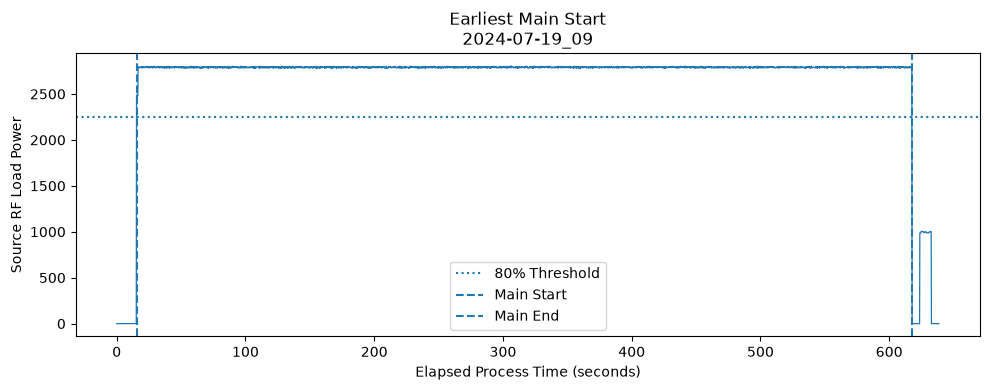

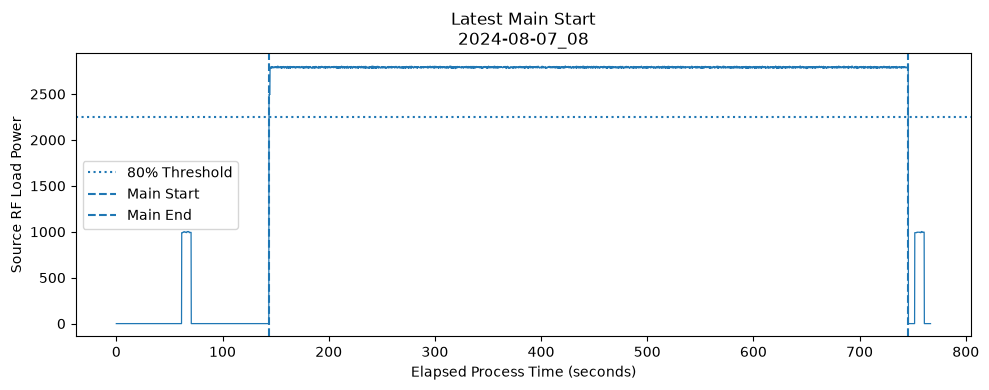

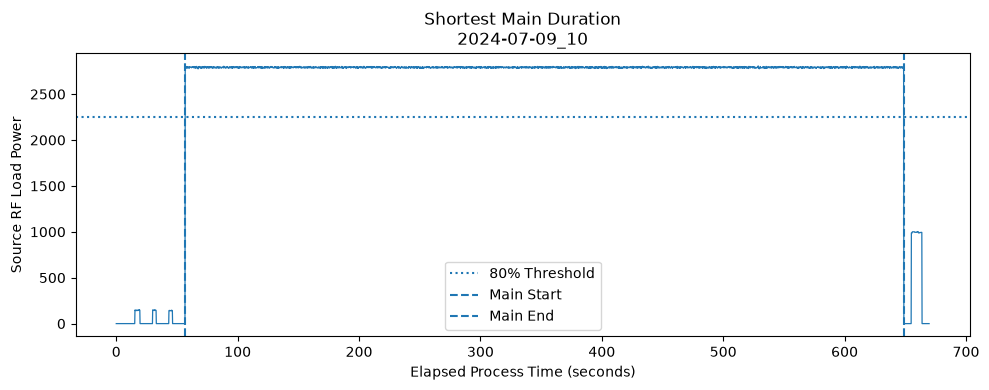

In [12]:
earliest_start_row = process_wafer_summary.loc[
    process_wafer_summary["main_active_start"].idxmin()
]

latest_start_row = process_wafer_summary.loc[
    process_wafer_summary["main_active_start"].idxmax()
]

shortest_duration_row = process_wafer_summary.loc[
    process_wafer_summary["main_active_duration"].idxmin()
]

validation_cases = pd.DataFrame(
    [
        {
            "case": "Earliest Main Start",
            **earliest_start_row[
                [
                    "group_name",
                    "experiment_key",
                    "lot_number",
                    "wafer_number",
                    "main_active_threshold",
                    "main_active_start",
                    "main_active_end",
                    "main_active_duration",
                ]
            ].to_dict(),
        },
        {
            "case": "Latest Main Start",
            **latest_start_row[
                [
                    "group_name",
                    "experiment_key",
                    "lot_number",
                    "wafer_number",
                    "main_active_threshold",
                    "main_active_start",
                    "main_active_end",
                    "main_active_duration",
                ]
            ].to_dict(),
        },
        {
            "case": "Shortest Main Duration",
            **shortest_duration_row[
                [
                    "group_name",
                    "experiment_key",
                    "lot_number",
                    "wafer_number",
                    "main_active_threshold",
                    "main_active_start",
                    "main_active_end",
                    "main_active_duration",
                ]
            ].to_dict(),
        },
    ]
)

display(validation_cases.round(2))

for _, case_row in validation_cases.iterrows():
    process_df, _, _ = load_process_wafer(
        case_row["group_name"]
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        process_df["elapsed_seconds"],
        process_df[SOURCE_POWER_FEATURE],
        linewidth=0.9,
    )

    ax.axhline(
        case_row["main_active_threshold"],
        linestyle=":",
        label="80% Threshold",
    )

    ax.axvline(
        case_row["main_active_start"],
        linestyle="--",
        label="Main Start",
    )

    ax.axvline(
        case_row["main_active_end"],
        linestyle="--",
        label="Main End",
    )

    ax.set_xlabel("Elapsed Process Time (seconds)")
    ax.set_ylabel("Source RF Load Power")
    ax.set_title(
        f"{case_row['case']}\n"
        f"{case_row['experiment_key']}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

### 這幾個極端案例實際告訴我們什麼？

三個案例分別是：

**Main Start 最早**
- `2024-07-19_09`
- Start ≈ **15.40 秒**
- End ≈ **617.60 秒**
- Duration ≈ **602.2 秒**

**Main Start 最晚**
- `2024-08-07_08`
- Start ≈ **143.80 秒**
- End ≈ **745.80 秒**
- Duration ≈ **602.0 秒**

**Main Duration 最短**
- `2024-07-09_10`
- Start ≈ **56.81 秒**
- End ≈ **648.61 秒**
- Duration ≈ **591.8 秒**

雖然三片 wafer 的 start time 差很多，但從圖上看，偵測到的 start / end 仍然落在各自主要長時間 `SourceRFLoadPower` 高功率平台的前後。

因此可以比較保守地說：**80% heuristic 在目前選到的代表性 edge cases 上，和 waveform 的主要 plateau 對得起來。**

不過這仍然只是 visual sanity check，不代表 threshold 已經被獨立資料正式驗證。


# Part D｜Process Sequence Effect

## 12. Process Signal 會不會也隨 Wafer Sequence 改變？

前面 02 已經看到 Mean Si Etch 在 10 / 10 Lots 中都往後下降。

現在我改看 Process 端，只使用每片 wafer **Main Active Window 的 signal mean**，對每個：

`Process Feature × Lot`

計算：

- Linear slope
- Linear R²
- Spearman correlation
- 第一片到最後一片的變化
- 是否幾乎沒有變化

這裡的 `main_mean` 只是一個 EDA level summary。像 std、range、phase、early-late difference 這類更完整的特徵會留到後面的 Feature Engineering，不在 03 重複做。


In [13]:
main_mean_columns = [
    column
    for column in process_wafer_summary.columns
    if column.startswith("main_mean__")
]

assert len(main_mean_columns) == 27

process_sequence_records = []

for mean_column in main_mean_columns:
    feature_name = mean_column.replace("main_mean__", "")

    for lot_number, group in (
        process_wafer_summary.groupby("lot_number")
    ):
        group = group.sort_values("wafer_number")

        x = group["wafer_number"].to_numpy(dtype=float)
        y = group[mean_column].to_numpy(dtype=float)

        is_flat = np.allclose(
            y,
            y[0],
            rtol=1e-7,
            atol=1e-8,
        )

        if is_flat:
            slope = 0.0
            intercept = float(np.mean(y))
            r2 = np.nan
            spearman_rho = np.nan
            observed_change = 0.0
            trend_direction = "Stable"
        else:
            slope, intercept = np.polyfit(x, y, deg=1)

            predicted = intercept + slope * x

            ss_total = np.sum((y - y.mean()) ** 2)
            ss_residual = np.sum((y - predicted) ** 2)

            r2 = (
                1 - ss_residual / ss_total
                if ss_total > 0
                else np.nan
            )

            spearman_rho = (
                pd.Series(x)
                .corr(
                    pd.Series(y),
                    method="spearman",
                )
            )

            observed_change = float(y[-1] - y[0])

            trend_direction = (
                "Increasing"
                if slope > 0
                else "Decreasing"
            )

        process_sequence_records.append(
            {
                "feature": feature_name,
                "lot_number": int(lot_number),
                "n_wafers": len(group),
                "is_flat": bool(is_flat),
                "trend_direction": trend_direction,
                "slope_per_wafer": float(slope),
                "linear_r2": float(r2) if np.isfinite(r2) else np.nan,
                "spearman_rho": (
                    float(spearman_rho)
                    if pd.notna(spearman_rho)
                    else np.nan
                ),
                "first_value": float(y[0]),
                "last_value": float(y[-1]),
                "observed_change": observed_change,
            }
        )

process_sequence_by_lot = pd.DataFrame(
    process_sequence_records
)

assert len(process_sequence_by_lot) == 270
assert (
    process_sequence_by_lot
    .groupby("feature")["lot_number"]
    .nunique()
    .eq(10)
    .all()
)

print("Process Sequence Rows：", len(process_sequence_by_lot))
process_sequence_by_lot.head(20)

Process Sequence Rows： 270


,feature,lot_number,n_wafers,is_flat,trend_direction,slope_per_wafer,linear_r2,spearman_rho,first_value,last_value,observed_change
0,Stat3_Etch_MV_EpdIntensity,1,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
1,Stat3_Etch_MV_EpdIntensity,2,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
2,Stat3_Etch_MV_EpdIntensity,3,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
3,Stat3_Etch_MV_EpdIntensity,4,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
4,Stat3_Etch_MV_EpdIntensity,5,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
5,Stat3_Etch_MV_EpdIntensity,6,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
6,Stat3_Etch_MV_EpdIntensity,7,6,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
7,Stat3_Etch_MV_EpdIntensity,8,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
8,Stat3_Etch_MV_EpdIntensity,9,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000
9,Stat3_Etch_MV_EpdIntensity,10,10,True,Stable,0.000000,NaN,NaN,0.123000,0.123000,0.000000


### 這個結果實際告訴我們什麼？

一共得到：

**27 Features × 10 Lots = 270 組 Feature-Lot sequence results**

其中 `EpdIntensity` 在 Main Active Window 裡的 wafer-level mean 幾乎固定，所以 10 個 Lots 都被標成：

- `Stable`
- slope = 0
- R² = `NaN`
- Spearman = `NaN`

這不是程式錯誤，也不和前面完整 trace 中 `EpdIntensity` 有變化互相矛盾。

原因是：它的主要變化發生在 Main Active Window 之外；進入主要製程區段後，它的 wafer-level mean 幾乎沒有變化。

所以這裡可以清楚分成兩個不同問題：

- 完整 time series 裡 signal 有沒有 state transition
- 主要製程區段的 wafer-level mean 有沒有 sequence variation

兩者不能混在一起解讀。


## 13. 把 270 組結果整理成 27 個 Feature-Level Summary

接著把每個 feature 在 10 個 Lots 的 sequence 結果整理在一起，我主要看：

- 幾個 Lots 是 Increasing
- 幾個是 Decreasing
- 幾個是 Stable
- 最常出現的方向是哪一個
- 有幾個 Lots 和 dominant direction 一致
- Median Spearman
- Median |Spearman|
- Median R²

不同 sensors 的單位差很多，所以 raw slope 數值不適合直接跨 feature 比大小。

因此這裡比較重視：

1. 趨勢方向在多少 Lots 中一致
2. median absolute Spearman 有多大

這樣比較能看出某個 sequence pattern 是不是在多個 Lots 中反覆出現。


In [14]:
process_sequence_summary_records = []

for feature, group in process_sequence_by_lot.groupby("feature"):
    n_lots = len(group)

    n_increasing = int(
        (group["trend_direction"] == "Increasing").sum()
    )
    n_decreasing = int(
        (group["trend_direction"] == "Decreasing").sum()
    )
    n_stable = int(
        (group["trend_direction"] == "Stable").sum()
    )

    if n_stable == n_lots:
        dominant_direction = "Stable"
        same_direction_lots = 0
    elif n_increasing > n_decreasing:
        dominant_direction = "Increasing"
        same_direction_lots = n_increasing
    elif n_decreasing > n_increasing:
        dominant_direction = "Decreasing"
        same_direction_lots = n_decreasing
    else:
        dominant_direction = "Mixed"
        same_direction_lots = max(
            n_increasing,
            n_decreasing,
        )

    process_sequence_summary_records.append(
        {
            "feature": feature,
            "n_lots": n_lots,
            "positive_slope_lots": n_increasing,
            "negative_slope_lots": n_decreasing,
            "zero_slope_lots": n_stable,
            "dominant_direction": dominant_direction,
            "same_direction_lots": int(same_direction_lots),
            "direction_consistency_pct": (
                same_direction_lots / n_lots * 100
            ),
            "median_slope": group["slope_per_wafer"].median(),
            "median_spearman": group["spearman_rho"].median(skipna=True),
            "median_abs_spearman": (
                group["spearman_rho"]
                .abs()
                .median(skipna=True)
            ),
            "median_r2": group["linear_r2"].median(skipna=True),
            "n_valid_spearman": int(
                group["spearman_rho"].notna().sum()
            ),
        }
    )

process_sequence_summary = (
    pd.DataFrame(process_sequence_summary_records)
    .sort_values(
        ["same_direction_lots", "median_abs_spearman"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

assert len(process_sequence_summary) == 27

consistent_sequence_features = (
    process_sequence_summary.loc[
        process_sequence_summary["same_direction_lots"] >= 8
    ].copy()
)

very_consistent_features = (
    process_sequence_summary.loc[
        process_sequence_summary["same_direction_lots"] >= 9
    ].copy()
)

perfect_direction_features = (
    process_sequence_summary.loc[
        process_sequence_summary["same_direction_lots"] == 10
    ].copy()
)

print(
    "至少 8 / 10 Lots 同方向：",
    len(consistent_sequence_features),
)
print(
    "至少 9 / 10 Lots 同方向：",
    len(very_consistent_features),
)
print(
    "10 / 10 Lots 同方向：",
    len(perfect_direction_features),
)

display(
    perfect_direction_features[
        [
            "feature",
            "dominant_direction",
            "positive_slope_lots",
            "negative_slope_lots",
            "zero_slope_lots",
            "median_spearman",
            "median_abs_spearman",
            "median_r2",
        ]
    ]
)

consistency_distribution = (
    process_sequence_summary["same_direction_lots"]
    .value_counts()
    .sort_index()
    .rename_axis("same_direction_lots")
    .reset_index(name="n_features")
)

display(consistency_distribution)

至少 8 / 10 Lots 同方向： 15
至少 9 / 10 Lots 同方向： 8
10 / 10 Lots 同方向： 6


,feature,dominant_direction,positive_slope_lots,negative_slope_lots,zero_slope_lots,median_spearman,median_abs_spearman,median_r2
0,Stat3_Etch_MV_PlatenRFTuningCapacitor,Increasing,10,0,0,0.957576,0.957576,0.823633
1,Stat3_Etch_MV_SourceRFPeakToPeak,Decreasing,0,10,0,-0.806061,0.806061,0.640510
2,Stat3_Etch_MV_ForeLinePressure,Decreasing,0,10,0,-0.775758,0.775758,0.620112
3,Stat3_Etch_MV_PlatenRFPeakToPeak,Increasing,10,0,0,0.769697,0.769697,0.600255
4,Stat3_Etch_MV_SourceRFLoadPower,Decreasing,0,10,0,-0.672727,0.672727,0.404347
5,Stat3_Etch_MV_SourceRFReflectedPower,Increasing,10,0,0,0.490909,0.490909,0.244934


,same_direction_lots,n_features
0,0,2
1,3,1
2,5,1
3,6,4
4,7,4
5,8,7
6,9,2
7,10,6


### 這個結果實際告訴我們什麼？

結果顯示：

- **15 / 27** 個 features 至少在 **8 / 10 Lots** 出現相同方向
- **8 / 27** 個 features 至少在 **9 / 10 Lots** 同方向
- **6 / 27** 個 features 在 **10 / 10 Lots** 全部同方向

6 個 10/10 的 features 是：

| Feature | 主要方向 | Median Spearman | Median R² |
|---|---|---:|---:|
| PlatenRFTuningCapacitor | Increasing | 約 0.958 | 約 0.824 |
| SourceRFPeakToPeak | Decreasing | 約 -0.806 | 約 0.641 |
| ForeLinePressure | Decreasing | 約 -0.776 | 約 0.620 |
| PlatenRFPeakToPeak | Increasing | 約 0.770 | 約 0.600 |
| SourceRFLoadPower | Decreasing | 約 -0.673 | 約 0.404 |
| SourceRFReflectedPower | Increasing | 約 0.491 | 約 0.245 |

這表示 Process sequence effect 不是只出現在單一 sensor，而是同時出現在多個 RF / pressure-related signals。

不過「10 / 10 Lots 都同方向」不等於 relationship 一定很強。例如 `SourceRFReflectedPower` 雖然方向完全一致，但 median Spearman 和 R² 都比前幾個低。

所以這裡比較合理的解讀是：**方向一致性告訴我這個趨勢是否反覆出現，Spearman 和 R² 再補充它的強度。兩者要一起看，不能只看其中一個。**


# Part E｜輸出 03 的 Process Artifacts

## 14. 把 Main Active Window 與 Process Sequence 結果固定下來

到這裡，03 已經把 Main Active Window 的定義和 96 片 wafer 的 Process summary 建立完成。

為了讓後面每份 Notebook 都使用同一套資料，我會輸出：

- `process_wafer_summary.csv`
- `process_sequence_by_lot.csv`
- `process_sequence_summary.csv`

後續用途是：

- 04：研究 sequence-adjusted Process–Quality relationship
- 05：建立 residual-based SPC screening
- 06：接著做 multivariate process analysis

這樣 Main Active Window 只在 03 定義一次，後面不需要再各自重切。


In [15]:
process_output_tables = {
    "process_wafer_summary.csv": process_wafer_summary,
    "process_sequence_by_lot.csv": process_sequence_by_lot,
    "process_sequence_summary.csv": process_sequence_summary,
}

for filename, dataframe in process_output_tables.items():
    dataframe.to_csv(
        PROCESSED_DATA_DIR / filename,
        index=False,
    )

process_output_checks = []

for filename, dataframe in process_output_tables.items():
    output_path = PROCESSED_DATA_DIR / filename
    reloaded = pd.read_csv(output_path)

    process_output_checks.append(
        {
            "file": filename,
            "exists": output_path.exists(),
            "rows_match": len(reloaded) == len(dataframe),
            "columns_match": list(reloaded.columns) == list(dataframe.columns),
        }
    )

process_output_checks_df = pd.DataFrame(
    process_output_checks
)

assert process_output_checks_df[
    ["exists", "rows_match", "columns_match"]
].all().all()

assert len(pd.read_csv(
    PROCESSED_DATA_DIR / "process_wafer_summary.csv"
)) == 96

assert len(pd.read_csv(
    PROCESSED_DATA_DIR / "process_sequence_by_lot.csv"
)) == 270

assert len(pd.read_csv(
    PROCESSED_DATA_DIR / "process_sequence_summary.csv"
)) == 27

process_output_checks_df

,file,exists,rows_match,columns_match
0,process_wafer_summary.csv,True,True,True
1,process_sequence_by_lot.csv,True,True,True
2,process_sequence_summary.csv,True,True,True


### 這個結果實際告訴我們什麼？

三個輸出檔案的：

- `exists`
- `rows_match`
- `columns_match`

全部都是 `True`。

目前 row counts 是：

- `process_wafer_summary.csv` → **96 rows**
- `process_sequence_by_lot.csv` → **270 rows**
- `process_sequence_summary.csv` → **27 rows**

這一格不是新的製程分析結果，而是在確認剛才算出的資料真的有完整寫進檔案，而且重新讀回後 rows 和 columns 都沒有改變。

也就是說，04、05、06 接下來讀到的會是和這份 Notebook 當下完全相同的 03 結果。


# 15. 03 整體結論

這份 03 的重點，是把 Raw Process time series 整理成後面可以直接使用的 wafer-level Process 資料，並確認 **Process 端本身也有明顯的 wafer-sequence structure**。

先從資料完整性來看，Raw NetCDF 一共有 **96 片 Process Wafers**，Lot 數和 01 完全一致。01 已發現的 **69 片 terminal-gap wafers** 在這裡也全部對得上，所以 03 沒有另外改寫時間軸 QC 規則。

接著從 waveform 來看，27 個 usable features 在完整 continuous segment 中都有變化，但變化型態差很多。有些主要是 transition，有些是 cyclic switching，有些則會形成長時間 plateau。這也是為什麼我沒有直接用整段 trace 的平均值代表所有製程資訊。

Main Active Window 使用 `SourceRFLoadPower` 的 80% wafer-level max threshold 來抓最長高功率區段。96 片 wafer 都能成功找到這個區段，而且 duration 很集中：

- Mean ≈ **597.54 秒**
- Median ≈ **598.0 秒**
- Min = **591.8 秒**
- Max = **602.2 秒**

雖然每片 wafer 的 Main Start 最早約 **15.4 秒**、最晚約 **143.8 秒**，位置差很多，但主要製程區段本身長度非常接近。Threshold sensitivity 也顯示 70%–85% 的結果和 80% 幾乎相同，90% 的最大 duration shift 也只有 **1.2 秒**。所以目前這個 segmentation 對鄰近 threshold 不算敏感。

最後，Process sequence analysis 得到 **270 組 Feature-Lot 結果**。其中：

- **15 / 27** 個 features 至少在 8 / 10 Lots 同方向
- **8 / 27** 個 features 至少在 9 / 10 Lots 同方向
- **6 / 27** 個 features在 10 / 10 Lots 都同方向

這表示多個 wafer-level Process summaries 具有明顯的 Lot 內 wafer-sequence structure；尤其多個 RF / pressure-related signals 會隨 wafer sequence 系統性改變。這裡描述的是觀察到的 sequence pattern，沒有另外做正式的 time-series stationarity test。

把這個結果和 02 放在一起看，就得到這份 Notebook 最重要的結論：

> **Quality 會隨 wafer sequence 改變，Process signals 也會隨 wafer sequence 改變。**

因此下一步如果直接把所有 wafer 混在一起算 Process–Quality correlation，很可能會把共同的 sequence trend 當成 Process 對 Quality 的關係。

所以 04 必須直接使用這份 03 輸出的 `process_wafer_summary.csv`，先處理 Lot / Wafer Sequence structure，再研究 Process–Quality association。
